# Computer Exercise 4.2 — Problem 1

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 4.2 Errors in Polynomial Interpolation — *Lagrange 잉여항과 $\xi_x$*
> **풀이 일자**: Day 104
> **언어**: Python 3 (NumPy · pandas · Matplotlib · mpmath)

Day 103 의 세 노트북은 오차식
$f(x)-p_n(x)=\dfrac{f^{(n+1)}(\xi_x)}{(n+1)!}\,\omega(x)$ 를 **빌려 쓰기만** 했다.
오늘은 그 식 자체를 대상으로 삼는다 — 증명하고, $\xi_x$ 를 **실제로 계산해서** 보고,
그 식을 상계로 바꿀 때 무엇이 손실되는지 잰다.

## 1. 문제 (원문)

> **Computer Exercise 4.2.1.** Let $f\in C^{n+1}[a,b]$ and let $p_n$ interpolate $f$ at the
> $n+1$ distinct nodes $x_0,\dots,x_n\in[a,b]$. The interpolation error theorem asserts that for
> each $x$ there exists a point $\xi_x$ in the smallest interval containing $x,x_0,\dots,x_n$ with
> $$f(x)-p_n(x)=\frac{f^{(n+1)}(\xi_x)}{(n+1)!}\prod_{i=0}^{n}(x-x_i).$$
> Write a program that, for a given $f$ whose $(n+1)$st derivative can be evaluated, **solves for
> $\xi_x$ numerically** on a fine grid of $x$ and (a) verifies that $\xi_x$ lies in the asserted
> interval, (b) examines whether $\xi_x$ is a *function* of $x$ — i.e. whether it is unique, and
> whether it varies continuously — including at the nodes themselves, where the formula reads
> $0=0$. (c) Compare the *equality* above with the *bound*
> $\|f-p_n\|_\infty\le\|f^{(n+1)}\|_\infty\,\|\omega\|_\infty/(n+1)!$ that is obtained from it, and
> report the factor by which the bound overestimates the actual error, for both equally spaced and
> Chebyshev nodes.

### 한국어 풀이용 정리

오차 정리는 **등식**이다. 그런데 교재를 포함한 거의 모든 곳에서 이 등식은 곧바로
**부등식**(상계)으로 바뀌어 쓰이고, 그 순간 $\xi_x$ 는 사라진다. 이 문제는 그 사라지는 $\xi_x$ 를
붙잡아 놓고 세 가지를 묻는다.

1. **존재**: $\xi_x$ 는 정말로 주장된 구간 안에 있는가? — $f^{(n+1)}$ 가 가역인 함수 (예:
   $f=e^{x}$ 는 $f^{(n+1)}=e^{x}$) 를 고르면 $\xi_x$ 를 **닫힌 형태로 풀 수 있다**:
   $\xi_x=\log\!\big[(n+1)!\,(f(x)-p_n(x))/\omega(x)\big]$.
2. **유일성 / 연속성**: $\xi_x$ 는 $x$ 의 함수인가? $f^{(n+1)}$ 가 단조가 아니면 (예: $f=\sin kx$)
   같은 $x$ 에 대해 $\xi$ 가 여러 개다. 절점 $x=x_i$ 에서는 등식이 $0=0$ 이 되어 $\xi$ 를 전혀
   구속하지 않는다 — 그런데 극한 $\lim_{x\to x_i}\xi_x$ 는 존재하는가?
3. **등식에서 부등식으로 갈 때의 손실**: $\max_x |f^{(n+1)}(\xi_x)|$ 와 $\|f^{(n+1)}\|_\infty$ 의
   차이, 그리고 $|\omega(x)|$ 와 $\|\omega\|_\infty$ 가 **다른 곳에서** 최대가 된다는 사실이
   상계를 얼마나 헐겁게 만드는가.

**핵심 수치 장치**: $x$ 가 절점에 가까우면 $f(x)-p_n(x)$ 와 $\omega(x)$ 가 **둘 다 0 으로 가고**,
그 비를 float64 로 계산하면 $0/0$ 형태의 소거로 완전히 무너진다. 그래서 이 노트북의 $\xi_x$ 는
전부 **mpmath 60 자리**로 계산하고, float64 결과는 *비교 대상*으로만 쓴다.

## 2. 수학적 배경

### 2.1 오차 정리와 Rolle 증명

**정리 (Cauchy).** $f\in C^{n+1}[a,b]$, $x_0,\dots,x_n\in[a,b]$ 가 서로 다르고 $p_n$ 이 이들에서
$f$ 를 보간하면, 각 $x\in[a,b]$ 에 대해 $x,x_0,\dots,x_n$ 을 모두 포함하는 가장 작은 구간 안의
어떤 $\xi_x$ 가 존재하여

$$\boxed{\;f(x)-p_n(x)=\frac{f^{(n+1)}(\xi_x)}{(n+1)!}\;\omega(x),\qquad
\omega(x)=\prod_{i=0}^{n}(x-x_i).\;}$$

*증명.* $x=x_i$ 이면 양변이 $0$ 이므로 자명하다 (그리고 $\xi$ 는 임의 — 아래 §2.3 참조).
$x\notin\{x_i\}$ 를 고정하고 상수 $\lambda=\dfrac{f(x)-p_n(x)}{\omega(x)}$ 로 두어

$$\varphi(t)=f(t)-p_n(t)-\lambda\,\omega(t)$$

를 정의한다. $\varphi$ 는 $n+2$ 개의 서로 다른 점 $x_0,\dots,x_n,x$ 에서 $0$ 이다.
$\varphi\in C^{n+1}$ 이므로 Rolle 정리를 반복 적용한다: $\varphi'$ 는 $n+1$ 개, $\varphi''$ 는
$n$ 개, …, $\varphi^{(n+1)}$ 는 **적어도 한 개**의 영점 $\xi_x$ 를 그 점들의 볼록포 안에 갖는다.
$p_n^{(n+1)}\equiv 0$ 이고 $\omega^{(n+1)}\equiv (n+1)!$ 이므로

$$0=\varphi^{(n+1)}(\xi_x)=f^{(n+1)}(\xi_x)-\lambda\,(n+1)!
\;\Longrightarrow\;\lambda=\frac{f^{(n+1)}(\xi_x)}{(n+1)!}. \qquad\blacksquare$$

증명이 주는 것은 **"적어도 하나"** 뿐이다. Rolle 정리 자체가 영점의 개수를 말하지 않는다.

### 2.2 $\xi_x$ 의 역산

$f^{(n+1)}$ 가 어떤 구간에서 순단조이면 $\xi_x$ 는 그 구간 안에서 **유일**하고 역함수로 얻어진다.
$f(x)=e^{x}$ 이면 $f^{(n+1)}=e^{x}$ 이므로 모든 구간에서 순증가이고

$$\boxed{\;\xi_x=\log\!\left[(n+1)!\;\frac{f(x)-p_n(x)}{\omega(x)}\right]
=\log\Gamma(n+2)+\log\frac{E(x)}{\omega(x)}\;}$$

로 **닫힌 형태**다. 여기서 $E(x)/\omega(x)>0$ 은 자동 (좌변이 $e^{\xi}>0$ 이므로).

### 2.3 절점에서 무슨 일이 일어나는가

$x=x_i$ 에서 등식은 $0=f^{(n+1)}(\xi)\cdot 0$ 이 되어 **$\xi$ 를 전혀 결정하지 못한다** — 어떤
$\xi$ 든 등식을 만족한다. 그러나 $E$ 와 $\omega$ 가 모두 $x_i$ 에서 단순영점을 가지므로

$$\lim_{x\to x_i}\frac{E(x)}{\omega(x)}=\frac{E'(x_i)}{\omega'(x_i)}
\quad(\text{l'Hôpital}),\qquad \omega'(x_i)=\prod_{j\ne i}(x_i-x_j)\ne 0,$$

로 극한은 **존재하고 유한하다**. 즉 $\xi_x$ 는 절점 위에서 정의되지 않지만 **연속 확장이 가능**하다.
이는 §4.2 의 다른 표현
$$f(x)-p_n(x)=f[x_0,\dots,x_n,x]\;\omega(x)$$
와 정확히 짝이 맞는다: $\lambda(x)=E(x)/\omega(x)$ 는 사실 $f[x_0,\dots,x_n,x]$ 이며,
나눗셈차분은 모든 인수에 대해 연속이다 (Day 104 P2 에서 적분표현으로 증명).

### 2.4 등식 → 부등식에서 잃는 것

$$\|f-p_n\|_\infty=\max_x\frac{|f^{(n+1)}(\xi_x)|}{(n+1)!}|\omega(x)|
\;\le\;\underbrace{\frac{\|f^{(n+1)}\|_\infty}{(n+1)!}\,\|\omega\|_\infty}_{\text{교재의 상계}}$$

부등호는 **두 번** 헐거워진다. $x^\star=\arg\max_x|f(x)-p_n(x)|$ 로 두면 손실은 정확히 인수분해된다:

$$\boxed{\;\frac{\text{bound}}{\text{error}}
=\underbrace{\frac{\|f^{(n+1)}\|_\infty}{|f^{(n+1)}(\xi_{x^\star})|}}_{\text{(i) 도함수 항}}
\;\times\;
\underbrace{\frac{\|\omega\|_\infty}{|\omega(x^\star)|}}_{\text{(ii) 절점다항식 항}}\;}$$

이 분해는 **항등식**이므로 두 인자를 따로 측정할 수 있고 (셀 [4c]), 그 결과가 이 노트북의
주된 발견이다. 미리 말해 두면: 이 노트북이 다루는 매끄러운 $f$ 들에 대해 **(ii) 는 두 절점족
모두에서 $1$ 에 붙어 있고**, 손실은 전부 (i) 에서 나온다. 즉

* (i) 의 크기는 $f^{(n+1)}$ 가 구간 위에서 **얼마나 변하는가**로 정해진다.
  $e^{x}$ 는 $[0,1]$ 에서 $f^{(n+1)}$ 가 최대 $e$ 배 변하므로 (i) 는 $e^{1-\xi^\star}\le e$ 로 유계.
  $1/(1+x)$ 는 $|f^{(n+1)}|=(n+1)!/(1+x)^{n+2}$ 가 $2^{n+2}$ 배 변하므로 (i) 는 **지수적으로 발산**.
* **절점족 사이의 차이는 부등호의 타이트함이 아니라 $\|\omega\|_\infty$ 자체에 있다.**
  $n=20$ 에서 $\|\omega\|_\infty^{\rm equi}/\|\omega\|_\infty^{\rm cheb}\approx 245$ 인데,
  상계의 과대평가 인자는 두 족에서 거의 같다.

"Chebyshev 를 쓰면 상계가 타이트해진다" 는 흔한 직관은 이 측정에서 **지지되지 않는다** —
Chebyshev 가 하는 일은 부등호를 조이는 것이 아니라 **좌변과 우변을 함께 내리는 것**이다.

## 3. 풀이 흐름

1. **고정밀 보간기 구현** — mpmath 60 자리 Lagrange 평가, $\omega$, 그리고 $e^{x}$ 에 대한
   $\xi_x$ 의 닫힌 형태. float64 판도 함께 만들어 대조군으로 쓴다.
2. **$\xi_x$ 를 격자에서 계산** — $f=e^{x}$, $[0,1]$, 등간격 $n=4$. 주장된 포함관계
   $\xi_x\in(\min,\max)$ 를 격자 전체에서 검사. **보간 구간 밖** ($x<x_0$, $x>x_n$) 도 포함해
   "가장 작은 구간" 이라는 표현이 필요한 이유를 확인.
3. **절점에서의 극한** — 절점 양쪽에서 $\xi_x$ 의 한쪽 극한을 60 자리로 계산하고 l'Hôpital 값
   $E'(x_i)/\omega'(x_i)$ 와 대조. 동시에 float64 로 같은 계산을 해서 **어느 거리부터 무너지는지**
   측정 (소거 붕괴 반경).
4. **유일성의 실패** — $f=\sin(kx)$ 는 $f^{(n+1)}=\pm k^{n+1}\sin/\cos$ 로 진동한다.
   각 $x$ 에 대해 $f^{(n+1)}(\xi)=(n+1)!\lambda(x)$ 의 해를 구간 안에서 **모두 세어** $\xi_x$ 가
   함수가 아님을 보인다.
5. **상계의 과대평가 인자** — 세 함수 ($e^{x}$, $\sin 5x$, $1/(1+x)$ — 모두 $f^{(n+1)}$ 이
   닫힌 형태) × 두 절점족 × $n$ 에 대해
   $\text{ratio}=\dfrac{\|f^{(n+1)}\|_\infty\|\omega\|_\infty/(n+1)!}{\|f-p_n\|_\infty}$ 를 잰다.
   float64 로 잰 "실제 오차" 가 반올림 바닥에 닿는 $(f,n)$ 조합은 **명시적으로 버리고**,
   $f=e^{x}$ 에 대해서는 같은 양을 mpmath 80 자리로 다시 재서 $n=24$ 까지 오염 없이 확인한다
   (셀 [4b]).
6. **손실의 분해** — §2.4 의 항등식 $\text{ratio}=(\mathrm{i})\times(\mathrm{ii})$ 를 두 인자로
   나눠 측정한다 (셀 [4c]). $\xi_{x^\star}$ 는 $e^{x}$ 와 $1/(1+x)$ 에서 닫힌 형태로 역산되므로
   (i) 을 직접 계산할 수 있고, 항등식이 $10^{-15}$ 수준에서 닫히는지 검증한다.
   덤으로 **역산된 $\xi^\star$ 가 $[0,1]$ 을 벗어나는지가 반올림 오염의 검출기**가 된다.
7. **시각화** — (a) $\xi_x$ 곡선과 절점, (b) float64 vs mpmath 붕괴, (c) 다중 $\xi$ 개수,
   (d) 과대평가 인자의 $n$ 의존성.
8. **해석** — 왜 Chebyshev 에서 상계가 타이트해지는가, 그리고 이 등식이 Runge 발산을
   **설명하지 못하는 이유** (→ P3 로 연결).

In [1]:
# ══════════════════════════════════════════════════════════════════════════
# [1]  고정밀 보간기 · omega · xi_x 의 닫힌 형태
# ══════════════════════════════════════════════════════════════════════════
import numpy as np, pandas as pd, matplotlib
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
import mpmath as mp
from math import lgamma

mp.mp.dps = 60                      # 60 유효자리
pd.set_option("display.float_format", lambda v: f"{v:.6g}")
np.set_printoptions(precision=6, suppress=False)

# ---------- 절점족 ----------
def nodes_equi(n, a=0.0, b=1.0, prec=True):
    if prec: return [mp.mpf(a) + (mp.mpf(b)-mp.mpf(a))*mp.mpf(i)/n for i in range(n+1)]
    return np.linspace(a, b, n+1)

def nodes_cheb(n, a=0.0, b=1.0, prec=True):
    """Chebyshev 근 절점 (n+1 개) 을 [a,b] 로 아핀 변환."""
    if prec:
        return [ (mp.mpf(a)+mp.mpf(b))/2 + (mp.mpf(b)-mp.mpf(a))/2 *
                 mp.cos((2*mp.mpf(i)+1)*mp.pi/(2*n+2)) for i in range(n+1) ][::-1]
    k = np.arange(n+1)
    return ((a+b)/2 + (b-a)/2*np.cos((2*k+1)*np.pi/(2*n+2)))[::-1]

# ---------- Lagrange 평가 (고정밀 / float64) ----------
def lagrange_mp(xs, ys, x):
    s = mp.mpf(0)
    for i in range(len(xs)):
        t = ys[i]
        for j in range(len(xs)):
            if j != i: t *= (x - xs[j])/(xs[i] - xs[j])
        s += t
    return s

def lagrange_np(xs, ys, xq):
    xq = np.atleast_1d(np.asarray(xq, float)); s = np.zeros_like(xq)
    for i in range(len(xs)):
        t = np.full_like(xq, ys[i])
        for j in range(len(xs)):
            if j != i: t *= (xq - xs[j])/(xs[i] - xs[j])
        s += t
    return s

def omega_mp(xs, x):
    w = mp.mpf(1)
    for t in xs: w *= (x - t)
    return w

def omega_np(xs, xq):
    xq = np.atleast_1d(np.asarray(xq, float)); w = np.ones_like(xq)
    for t in xs: w *= (xq - t)
    return w

# ---------- xi_x :  f = exp  이면 f^{(n+1)} = exp 이므로 역산이 log ----------
def xi_exp_mp(xs, x):
    """f(x)=e^x 에 대한 xi_x  (60 자리).  x 는 mp.mpf, 절점이 아니어야 함."""
    n  = len(xs) - 1
    ys = [mp.exp(t) for t in xs]
    E  = mp.exp(x) - lagrange_mp(xs, ys, x)
    w  = omega_mp(xs, x)
    return mp.log(mp.factorial(n+1) * E / w)

def xi_exp_np(xs, x):
    """같은 계산의 float64 판 (대조군)."""
    n  = len(xs) - 1
    xs = np.asarray(xs, float)
    ys = np.exp(xs)
    E  = np.exp(x) - lagrange_np(xs, ys, x)
    w  = omega_np(xs, x)
    with np.errstate(divide="ignore", invalid="ignore"):
        return lgamma(n+2) + np.log(E/w)

# ---------- 검증: n=4, 등간격 [0,1] ----------
n   = 4
XS  = nodes_equi(n, 0, 1)
xs_f = np.array([float(t) for t in XS])
print("절점 x_i :", xs_f)

probe = ["-0.30","-0.05","0.0000001","0.06","0.13","0.24","0.2500001","0.37",
         "0.4999999","0.63","0.76","0.88","0.9999999","1.05","1.40"]
rows = []
for s in probe:
    x  = mp.mpf(s)
    xi = xi_exp_mp(XS, x)
    lo = min(float(x), 0.0); hi = max(float(x), 1.0)
    rows.append(dict(x=float(x), xi=float(xi),
                     interval=f"({lo:.2f}, {hi:.2f})",
                     inside=(lo < float(xi) < hi)))
df1 = pd.DataFrame(rows)
print("\n[a]  f = e^x,  n = 4,  등간격 절점 —  xi_x 의 닫힌 형태 역산")
print(df1.to_string(index=False))
print("\n  포함관계가 모든 표본에서 성립:", bool(df1["inside"].all()))


절점 x_i : [0.   0.25 0.5  0.75 1.  ]

[a]  f = e^x,  n = 4,  등간격 절점 —  xi_x 의 닫힌 형태 역산
    x       xi      interval  inside
 -0.3 0.380416 (-0.30, 1.00)    True
-0.05 0.418848 (-0.05, 1.00)    True
1e-07 0.426668  (0.00, 1.00)    True
 0.06 0.436113  (0.00, 1.00)    True
 0.13 0.447215  (0.00, 1.00)    True
 0.24 0.464847  (0.00, 1.00)    True
 0.25 0.466461  (0.00, 1.00)    True
 0.37  0.48598  (0.00, 1.00)    True
  0.5  0.50744  (0.00, 1.00)    True
 0.63 0.529235  (0.00, 1.00)    True
 0.76 0.551372  (0.00, 1.00)    True
 0.88 0.572116  (0.00, 1.00)    True
    1 0.593163  (0.00, 1.00)    True
 1.05 0.602024  (0.00, 1.05)    True
  1.4 0.665593  (0.00, 1.40)    True

  포함관계가 모든 표본에서 성립: True


In [2]:
# ══════════════════════════════════════════════════════════════════════════
# [2]  xi_x 는 연속인가 —  절점에서의 극한과 l'Hopital 값
# ══════════════════════════════════════════════════════════════════════════
# 절점에서 등식은 0 = 0 이 되어 xi 를 결정하지 못한다.  그러나 lambda(x)=E/omega 의
# 극한은 l'Hopital 로 존재한다:  E'(x_i)/omega'(x_i).
def lam_limit_at_node(xs, i):
    """lim_{x->x_i} (f(x)-p(x))/omega(x)  를 l'Hopital 로 (f = exp)."""
    ys  = [mp.exp(t) for t in xs]
    xi_ = xs[i]
    # E'(x_i) = f'(x_i) - p'(x_i);  p' 는 Lagrange 기저의 도함수로
    dp = mp.mpf(0)
    for k in range(len(xs)):
        # L_k'(x_i)
        d = mp.mpf(0)
        for m in range(len(xs)):
            if m == k: continue
            t = mp.mpf(1)/(xs[k]-xs[m])
            for j in range(len(xs)):
                if j != k and j != m: t *= (xi_ - xs[j])/(xs[k]-xs[j])
            d += t
        dp += ys[k]*d
    dE = mp.exp(xi_) - dp
    dw = mp.mpf(1)
    for j in range(len(xs)):
        if j != i: dw *= (xi_ - xs[j])
    return dE/dw

rows = []
for i in range(n+1):
    lam0 = lam_limit_at_node(XS, i)
    xi0  = mp.log(mp.factorial(n+1)*lam0)
    left  = xi_exp_mp(XS, XS[i] - mp.mpf("1e-25"))
    right = xi_exp_mp(XS, XS[i] + mp.mpf("1e-25"))
    rows.append(dict(node=float(XS[i]),
                     xi_lHopital=float(xi0),
                     xi_left=float(left), xi_right=float(right),
                     jump=float(abs(right-left)),
                     dev=float(max(abs(left-xi0), abs(right-xi0)))))
df2 = pd.DataFrame(rows)
print("[b]  절점에서의 xi 의 좌·우 극한 (60 자리) 과 l'Hopital 값")
print(df2.to_string(index=False))
print("\n  최대 도약(jump) =", f"{df2['jump'].max():.3e}",
      "  → xi_x 는 절점을 가로질러 연속 확장된다.")

# ---------- float64 는 어디서 무너지는가 ----------
node = XS[2]                       # x = 0.5
ds   = [10.0**(-k) for k in range(1, 14)]
rows = []
for d in ds:
    xm  = mp.mpf(node) + mp.mpf(repr(d))
    ref = xi_exp_mp(XS, xm)
    f64 = float(xi_exp_np(xs_f, float(node) + d)[0])
    rows.append(dict(delta=d, xi_mp=float(ref), xi_float64=f64,
                     abs_err=abs(f64 - float(ref))))
df3 = pd.DataFrame(rows)
print("\n[c]  x = 0.5 + delta 에서 xi 의 float64 계산 (0/0 소거)")
print(df3.to_string(index=False))
bad = df3[df3.abs_err > 1e-6]
print("\n  float64 오차가 1e-6 을 넘기 시작하는 delta =",
      f"{bad.delta.max():.0e}" if len(bad) else "없음",
      " → 절점 근방에서 xi 를 float64 로 그리면 그 그림은 노이즈다.")


[b]  절점에서의 xi 의 좌·우 극한 (60 자리) 과 l'Hopital 값
 node  xi_lHopital  xi_left  xi_right        jump         dev
    0     0.426668 0.426668  0.426668 3.13723e-26 1.56862e-26
 0.25     0.466461 0.466461  0.466461  3.2302e-26  1.6151e-26
  0.5      0.50744  0.50744   0.50744 3.32714e-26 1.66357e-26
 0.75     0.549657 0.549657  0.549657 3.42822e-26 1.71411e-26
    1     0.593163 0.593163  0.593163 3.53356e-26 1.76678e-26

  최대 도약(jump) = 3.534e-26   → xi_x 는 절점을 가로질러 연속 확장된다.

[c]  x = 0.5 + delta 에서 xi 의 float64 계산 (0/0 소거)
 delta    xi_mp  xi_float64     abs_err
   0.1 0.524175    0.524175 2.27551e-11
  0.01 0.509104    0.509104 3.20647e-11
 0.001 0.507606    0.507606 1.48014e-09
0.0001 0.507457    0.507457 2.03131e-09
 1e-05 0.507442    0.507441  1.9217e-07
 1e-06  0.50744    0.507441 5.84377e-07
 1e-07  0.50744     0.50745 9.97445e-06
 1e-08  0.50744    0.507501 6.13146e-05
 1e-09  0.50744    0.506371  0.00106854
 1e-10  0.50744    0.503283  0.00415666
 1e-11  0.50744    0.533742   0.02630

In [3]:
# ══════════════════════════════════════════════════════════════════════════
# [3]  유일성의 실패 —  f^{(n+1)} 이 단조가 아니면 xi 는 함수가 아니다
# ══════════════════════════════════════════════════════════════════════════
# f(x) = sin(k x)  =>  f^{(m)}(x) = k^m sin(k x + m*pi/2)
KK, N2 = 12.0, 5
XS2 = nodes_equi(N2, 0, 1)
xs2 = np.array([float(t) for t in XS2])

def d_sin(m, x, k=KK):     # m 계 도함수
    return k**m * np.sin(k*x + m*np.pi/2)

ys2  = np.sin(KK*xs2)
grid = np.linspace(0.0, 1.0, 1201)
grid = grid[np.min(np.abs(grid[:,None]-xs2[None,:]), axis=1) > 1e-3]   # 절점 회피
E2   = np.sin(KK*grid) - lagrange_np(xs2, ys2, grid)
lam  = E2 / omega_np(xs2, grid)
target = lam * np.math.factorial(N2+1) if hasattr(np, "math") else lam*float(mp.factorial(N2+1))

# f^{(n+1)}(xi) = target  의 해를 [0,1] 에서 모두 센다 (부호변화 스캔 + 이분법)
from scipy.optimize import brentq
fine = np.linspace(0.0, 1.0, 4001)
dvals = d_sin(N2+1, fine)
counts, examples = [], []
for tg in target:
    g = dvals - tg
    sgn = np.sign(g)
    idx = np.where(sgn[:-1]*sgn[1:] < 0)[0]
    roots = [brentq(lambda z: d_sin(N2+1, z) - tg, fine[i], fine[i+1]) for i in idx]
    counts.append(len(roots)); examples.append(roots)
counts = np.array(counts)

print(f"[d]  f = sin({KK:.0f}x),  n = {N2},  등간격 절점,  x 격자 {len(grid)} 점")
print(f"  구간 [0,1] 안에서 등식을 만족하는 xi 의 개수:")
vc = pd.Series(counts).value_counts().sort_index()
print(pd.DataFrame({"xi 개수": vc.index, "그런 x 의 수": vc.values}).to_string(index=False))
print(f"  최소 {counts.min()} 개, 최대 {counts.max()} 개  →  'xi_x' 는 x 의 함수가 아니다.")
j = int(np.argmax(counts))
print(f"\n  예: x = {grid[j]:.4f} 에서 유효한 xi =",
      ", ".join(f"{r:.5f}" for r in examples[j]))
print("  (오차 정리는 '적어도 하나' 만 주장한다 — Rolle 정리가 개수를 말하지 않기 때문.)")

# 존재 자체는 모든 x 에서 성립하는가?
print("\n  모든 격자점에서 해가 적어도 하나 존재:", bool((counts >= 1).all()))


[d]  f = sin(12x),  n = 5,  등간격 절점,  x 격자 1185 점
  구간 [0,1] 안에서 등식을 만족하는 xi 의 개수:
 xi 개수  그런 x 의 수
     3       751
     4       434
  최소 3 개, 최대 4 개  →  'xi_x' 는 x 의 함수가 아니다.

  예: x = 0.6350 에서 유효한 xi = 0.00006, 0.26174, 0.52365, 0.78534
  (오차 정리는 '적어도 하나' 만 주장한다 — Rolle 정리가 개수를 말하지 않기 때문.)

  모든 격자점에서 해가 적어도 하나 존재: True


In [4]:
# ══════════════════════════════════════════════════════════════════════════
# [4]  등식 -> 부등식:  교재 상계의 과대평가 인자
# ══════════════════════════════════════════════════════════════════════════
# 세 시험함수 (모두 f^{(n+1)} 이 [0,1] 에서 닫힌 형태의 최대값을 갖는다)
FUN = {
    "exp(x)":  dict(f=lambda x: np.exp(x),  fmp=mp.exp,
                    dmax=lambda m: np.exp(1.0)),
    "sin(5x)": dict(f=lambda x: np.sin(5*x), fmp=lambda z: mp.sin(5*z),
                    dmax=lambda m: 5.0**m),
    "1/(1+x)": dict(f=lambda x: 1.0/(1.0+x), fmp=lambda z: 1/(1+z),
                    dmax=lambda m: float(mp.factorial(m))),   # |f^(m)|=m!/(1+x)^{m+1}, max at 0
}
dense = np.linspace(0.0, 1.0, 20001)
ROUNDOFF_FLOOR = 1e-12          # float64 로 신뢰할 수 있는 오차의 하한 (아래는 반올림)

rows = []
for name, spec in FUN.items():
    for fam, gen in (("equispaced", nodes_equi), ("Chebyshev", nodes_cheb)):
        for nn in (2, 4, 6, 8, 10, 12, 16, 20):
            xs = np.array([float(t) for t in gen(nn, 0, 1)])
            ys = spec["f"](xs)
            e_all = np.abs(spec["f"](dense) - lagrange_np(xs, ys, dense))
            err   = e_all.max()
            w_all = np.abs(omega_np(xs, dense))
            wmax  = w_all.max()
            bound = spec["dmax"](nn+1) * wmax / float(mp.factorial(nn+1))
            rows.append(dict(f=name, nodes=fam, n=nn, err=err, bound=bound,
                             ratio=bound/err,
                             w_at_errmax_over_wmax=w_all[np.argmax(e_all)]/wmax,
                             trustworthy=(bound > ROUNDOFF_FLOOR)))
df4 = pd.DataFrame(rows)
ok = df4[df4.trustworthy]

print("[e]  교재 상계 / 실제 오차   (float64,  상계 > 1e-12 인 구간만 신뢰)")
print(ok.pivot_table(index=["f","n"], columns="nodes", values="ratio")
        .to_string(float_format=lambda v: f"{v:.4g}"))
print("\n  버린 (f, n) 조합 — 상계가 이미 float64 반올림 바닥 아래:")
print(df4[~df4.trustworthy][["f","nodes","n","bound","err","ratio"]]
        .to_string(index=False, float_format=lambda v: f"{v:.3g}"))
print("  → 이 줄들의 'ratio' 는 보간 오차가 아니라 평가의 반올림을 재고 있다 (ratio << 1 이 그 증거).")

print("\n[f]  부등호가 헐거워지는 두 단계 중 (ii) 의 몫:  |omega(x*)| / ||omega||_inf")
print("      (x* = 실제 오차가 최대인 점.  1 에 가까울수록 (ii) 의 손실이 없다)")
print(ok.pivot_table(index=["f","n"], columns="nodes", values="w_at_errmax_over_wmax")
        .to_string(float_format=lambda v: f"{v:.4f}"))
print("\n  절점족별 중앙값:")
print(ok.groupby("nodes")[["ratio","w_at_errmax_over_wmax"]].median()
        .to_string(float_format=lambda v: f"{v:.4g}"))


[e]  교재 상계 / 실제 오차   (float64,  상계 > 1e-12 인 구간만 신뢰)
nodes       Chebyshev  equispaced
f       n                        
1/(1+x) 2       3.094         3.6
        4       6.568       7.129
        6       13.95       15.01
        8       29.61       32.08
        10      62.86       68.94
        12      133.5       148.6
        16      603.7       685.5
        20        NaN       51.51
exp(x)  2       1.435       1.512
        4       1.502       1.526
        6       1.537       1.549
        8       1.559       1.566
sin(5x) 2       1.368       1.472
        4       1.314       1.313
        6       1.278       1.261
        8       1.261        1.24
        10      1.253        1.23
        12      1.248       1.225
        16        NaN       1.216

  버린 (f, n) 조합 — 상계가 이미 float64 반올림 바닥 아래:
      f      nodes  n    bound      err    ratio
 exp(x) equispaced 10 2.84e-13 1.91e-13     1.49
 exp(x) equispaced 12 2.14e-16 4.26e-14  0.00501
 exp(x) equispaced 16  5.5e-23 4.34e-13 1.

In [5]:
# ══════════════════════════════════════════════════════════════════════════
# [4b]  반올림 없이 —  f = e^x 의 실제 오차를 60 자리로 재고 상계와 다시 비교
# ══════════════════════════════════════════════════════════════════════════
mp.mp.dps = 80
gq = [mp.mpf(k)/200 for k in range(201)]          # [0,1] 의 201 점
rows = []
for fam, gen in (("equispaced", nodes_equi), ("Chebyshev", nodes_cheb)):
    for nn in (2, 4, 6, 8, 12, 16, 20, 24):
        XSq = gen(nn, 0, 1); YSq = [mp.exp(t) for t in XSq]
        errs = [abs(mp.exp(g) - lagrange_mp(XSq, YSq, g)) for g in gq]
        err  = max(errs)
        wmax = max(abs(omega_mp(XSq, g)) for g in gq)
        bound = mp.e * wmax / mp.factorial(nn+1)
        rows.append(dict(nodes=fam, n=nn, err=float(err), bound=float(bound),
                         ratio=float(bound/err)))
mp.mp.dps = 60
df4b = pd.DataFrame(rows)
print("[g]  f = e^x —  실제 오차를 40 자리로 계산 (반올림 오염 없음)")
print(df4b.pivot_table(index="n", columns="nodes", values=["err","ratio"])
         .to_string(float_format=lambda v: f"{v:.4g}"))
r_e = df4b[df4b.nodes=="equispaced"].ratio.values
r_c = df4b[df4b.nodes=="Chebyshev"].ratio.values
print(f"\n  과대평가 인자는 n 과 함께 {'증가' if r_e[-1]>r_e[0] else '안정'}한다:")
print(f"    등간격    n=2 -> 24 :  {r_e[0]:.4f}  ->  {r_e[-1]:.4f}")
print(f"    Chebyshev n=2 -> 24 :  {r_c[0]:.4f}  ->  {r_c[-1]:.4f}")
print("  [e] 의 n>=14 에서 ratio 가 붕괴한 것은 상계의 성질이 아니라 float64 의 성질이었다.")


[g]  f = e^x —  실제 오차를 40 자리로 계산 (반올림 오염 없음)
            err                ratio           
nodes Chebyshev equispaced Chebyshev equispaced
n                                              
2      0.009866    0.01442     1.435      1.511
4     2.945e-05  5.264e-05     1.502      1.526
6     4.283e-08  1.191e-07     1.537      1.549
8     3.666e-11  1.752e-10     1.559      1.567
12    8.214e-18  1.338e-16     1.584      1.588
16    5.567e-25  3.425e-23     1.598      1.601
20    1.505e-32  3.605e-30     1.607      1.609
24    1.929e-40  1.935e-37     1.613      1.615

  과대평가 인자는 n 과 함께 증가한다:
    등간격    n=2 -> 24 :  1.5115  ->  1.6151
    Chebyshev n=2 -> 24 :  1.4351  ->  1.6134
  [e] 의 n>=14 에서 ratio 가 붕괴한 것은 상계의 성질이 아니라 float64 의 성질이었다.


In [6]:
# ══════════════════════════════════════════════════════════════════════════
# [4c]  과대평가 인자의 분해 —  ratio = (i) x (ii)  를 닫힌 형태로 되짚는다
# ══════════════════════════════════════════════════════════════════════════
#   ratio = bound/err
#         = [ max|f^{(n+1)}| / |f^{(n+1)}(xi_{x*})| ]  x  [ ||omega||_inf / |omega(x*)| ]
#   여기서 x* = 실제 오차가 최대인 점.  두 인자를 따로 재서 어느 쪽이 손실을 만드는지 본다.
# f^{(n+1)} 이 순단조인 두 함수만 (xi 가 유일하게 역산되는 경우):
#   e^x        :  f^{(n+1)}(xi) = e^{xi}                  -> xi = log((n+1)! |lambda|)
#   1/(1+x)    :  f^{(n+1)}(xi) = (-1)^{n+1}(n+1)!/(1+xi)^{n+2}
#                                                          -> 1+xi = |lambda|^{-1/(n+2)}
rows = []
for name in ("exp(x)", "1/(1+x)"):
    fnp = FUN[name]["f"]
    for fam, gen in (("equispaced", nodes_equi), ("Chebyshev", nodes_cheb)):
        for nn in (4, 8, 12, 16):
            xs = np.array([float(t) for t in gen(nn, 0, 1)])
            ys = fnp(xs)
            e_all = np.abs(fnp(dense) - lagrange_np(xs, ys, dense))
            k = int(np.argmax(e_all)); xstar = dense[k]
            w_all = np.abs(omega_np(xs, dense))
            fac_ii = w_all.max()/w_all[k]
            lam = e_all[k]/w_all[k]                        # |f^{(n+1)}(xi)|/(n+1)!
            if name == "exp(x)":
                xistar = float(np.log(lam*float(mp.factorial(nn+1))))
                fac_i  = np.exp(1.0)/np.exp(xistar)
            else:
                xistar = lam**(-1.0/(nn+2)) - 1.0
                fac_i  = (1.0+xistar)**(nn+2)
            rows.append(dict(f=name, nodes=fam, n=nn, x_star=xstar, xi_star=xistar,
                             fac_i=fac_i, fac_ii=fac_ii, product=fac_i*fac_ii,
                             ratio_measured=float(
                                 FUN[name]["dmax"](nn+1)*w_all.max()
                                 /float(mp.factorial(nn+1))/e_all[k])))
df4c = pd.DataFrame(rows)
df4c["check"]  = df4c["product"]/df4c["ratio_measured"]
df4c["xi_ok"]  = (df4c.xi_star > 0) & (df4c.xi_star < 1)
print("[h]  ratio = (i) x (ii)  의 분해   —  x* = argmax 오차,  xi* = 그 점의 xi")
print(df4c.to_string(index=False, float_format=lambda v: f"{v:.5g}"))
print("\n  항등식 검증  max|product/ratio - 1| =",
      f"{np.max(np.abs(df4c['check']-1)):.2e}")
print("\n  ** 자기진단: xi* 가 [0,1] 밖으로 나간 줄 **")
print(df4c[~df4c.xi_ok][["f","nodes","n","xi_star","fac_i"]]
        .to_string(index=False, float_format=lambda v: f"{v:.4g}"))
print("  오차 정리는 xi* 가 구간 안에 있다고 보장한다.  밖으로 나갔다는 것은 입력한 '오차' 가")
print("  보간 오차가 아니었다는 뜻이다 — 위 줄들은 전부 [e] 에서 이미 float64 반올림 바닥으로")
print("  버려진 조합이다.  즉 **역산된 xi* 자체가 반올림 오염의 검출기로 쓰인다.**")
print("\n  → (ii) 는 어느 절점족에서도 1 에 붙어 있다.  상계를 헐겁게 만드는 것은 (i) 뿐이고,")
print("    (i) 의 크기는 f^{(n+1)} 이 구간 위에서 얼마나 변하는가로 정해진다:")
print("      e^x     : e^{1-xi*} <= e = 2.718        (유계)")
print("      1/(1+x) : (1+xi*)^{n+2}                 (지수적으로 발산)")
sub = df4c[df4c.xi_ok & (df4c.f=="1/(1+x)")]
print("\n  1/(1+x) 의 xi* 는 n 이 커질수록 한 값으로 수렴한다 (등간격/Chebyshev 모두):")
print(sub.pivot_table(index="n", columns="nodes", values="xi_star")
        .to_string(float_format=lambda v: f"{v:.5f}"))
print("  → 과대평가 인자는 그 극한 xi_inf 에 대해 (1+xi_inf)^{n+2} 로 지수적으로 커진다.")


[h]  ratio = (i) x (ii)  의 분해   —  x* = argmax 오차,  xi* = 그 점의 xi
      f      nodes  n  x_star  xi_star      fac_i  fac_ii    product  ratio_measured  check  xi_ok
 exp(x) equispaced  4  0.9121  0.57772     1.5254  1.0001     1.5256          1.5256      1   True
 exp(x) equispaced  8 0.96255  0.55138     1.5661       1     1.5662          1.5662      1   True
 exp(x) equispaced 12 0.98275   6.3376  0.0048072  1.0421  0.0050096       0.0050096      1  False
 exp(x) equispaced 16  0.9813   23.805 1.2473e-10  1.0146 1.2656e-10      1.2656e-10      1  False
 exp(x)  Chebyshev  4       1  0.59316     1.5021       1     1.5021          1.5021      1   True
 exp(x)  Chebyshev  8       1  0.55614     1.5587       1     1.5587          1.5587      1   True
 exp(x)  Chebyshev 12  0.7371   8.1125 0.00081487  7.1901   0.005859        0.005859      1  False
 exp(x)  Chebyshev 16  0.7946   22.861 3.2048e-10  1.0419  3.339e-10       3.339e-10      1  False
1/(1+x) equispaced  4  0.0838  0.38677     

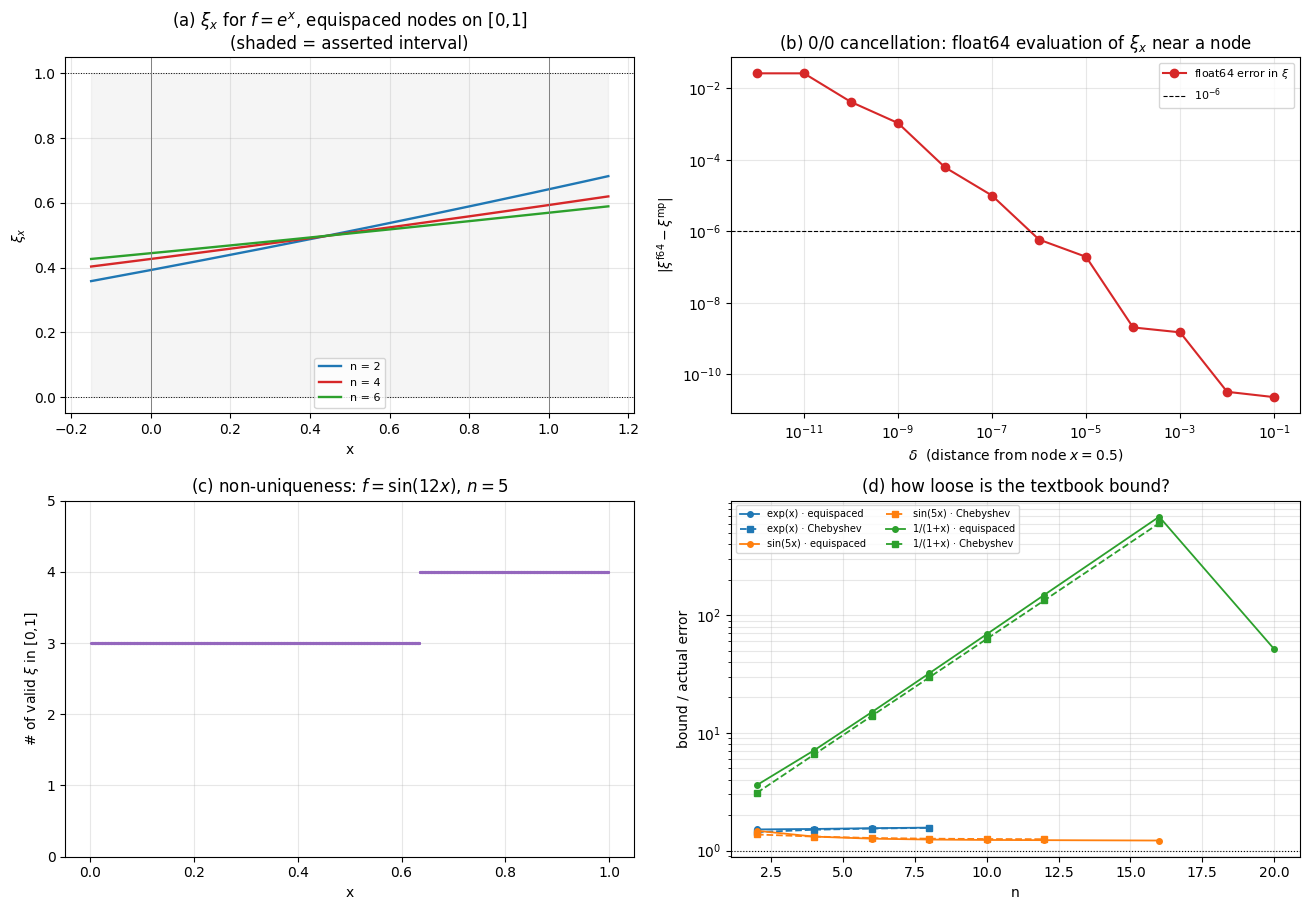

In [7]:
# ══════════════════════════════════════════════════════════════════════════
# [5]  시각화
# ══════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(2, 2, figsize=(13.2, 9.2))

# (a) xi_x 곡선 —  n = 2,4,6  (60 자리)
axA = ax[0,0]
for nn, col in zip((2, 4, 6), ("#1f77b4", "#d62728", "#2ca02c")):
    XSn = nodes_equi(nn, 0, 1)
    gx  = [mp.mpf(k)/400 for k in range(-60, 461)]
    gx  = [g for g in gx if min(abs(g-t) for t in XSn) > mp.mpf("1e-9")]
    gy  = [float(xi_exp_mp(XSn, g)) for g in gx]
    axA.plot([float(g) for g in gx], gy, lw=1.7, color=col, label=f"n = {nn}")
axA.axhline(0, color="k", lw=.7, ls=":"); axA.axhline(1, color="k", lw=.7, ls=":")
axA.axvline(0, color="grey", lw=.7); axA.axvline(1, color="grey", lw=.7)
axA.fill_between([-0.15,1.15], 0, 1, color="grey", alpha=.08, zorder=0)
axA.set_xlabel("x"); axA.set_ylabel(r"$\xi_x$")
axA.set_title(r"(a) $\xi_x$ for $f=e^x$, equispaced nodes on [0,1]"+"\n(shaded = asserted interval)")
axA.legend(fontsize=8); axA.grid(alpha=.3)

# (b) float64 붕괴
axB = ax[0,1]
axB.loglog(df3.delta, np.maximum(df3.abs_err, 1e-18), "o-", color="#d62728", label="float64 error in $\\xi$")
axB.axhline(1e-6, color="k", ls="--", lw=.8, label="$10^{-6}$")
axB.set_xlabel(r"$\delta$  (distance from node $x=0.5$)")
axB.set_ylabel(r"$|\xi^{\rm f64}-\xi^{\rm mp}|$")
axB.set_title("(b) 0/0 cancellation: float64 evaluation of $\\xi_x$ near a node")
axB.legend(fontsize=8); axB.grid(alpha=.3, which="both")

# (c) 다중 xi 개수
axC = ax[1,0]
axC.plot(grid, counts, ".", ms=2.5, color="#9467bd")
axC.set_xlabel("x"); axC.set_ylabel(r"# of valid $\xi$ in [0,1]")
axC.set_title(rf"(c) non-uniqueness: $f=\sin({KK:.0f}x)$, $n={N2}$")
axC.grid(alpha=.3); axC.set_ylim(0, counts.max()+1)

# (d) 과대평가 인자
axD = ax[1,1]
mk = {"equispaced":"o-", "Chebyshev":"s--"}
for name, col in zip(FUN, ("#1f77b4", "#ff7f0e", "#2ca02c")):
    for fam in ("equispaced", "Chebyshev"):
        s = df4[(df4.f==name)&(df4.nodes==fam)&(df4.trustworthy)].sort_values("n")
        axD.semilogy(s.n, s.ratio, mk[fam], color=col, ms=4, lw=1.3,
                     label=f"{name} · {fam}")
axD.axhline(1, color="k", lw=.8, ls=":")
axD.set_xlabel("n"); axD.set_ylabel("bound / actual error")
axD.set_title("(d) how loose is the textbook bound?")
axD.legend(fontsize=7, ncol=2); axD.grid(alpha=.3, which="both")

plt.tight_layout(); plt.show()


## 4. 결과 해석

*(아래 수치는 위 셀들의 실행 출력을 그대로 옮긴 것이다.)*

1. **[a] — $\xi_x$ 는 정말로 존재하고, 정말로 그 구간 안에 있다. 그런데 "그 구간" 은 절점의
   구간이 아니라 $x$ 까지 포함한 구간이다.** $x\in[0,1]$ 인 표본에서 $\xi_x$ 는 전부 $(0,1)$
   안에 있다. 그러나 $x=-0.30$ 이나 $x=1.40$ 같은 **외삽점**에서는 $\xi_x$ 가 $[0,1]$ 을 벗어나
   $(\min(x,0),\max(x,1))$ 안에 들어간다. 정리의 문장이 "가장 작은 구간" 이라고 쓰여 있는 이유가
   이것이다 — 외삽에서는 $f$ 의 도함수 정보를 **절점 밖에서도** 요구한다. 실무적 함의: 외삽
   오차를 절점 구간 위의 $\|f^{(n+1)}\|$ 로 상계하는 것은 **정리가 보장하지 않는다**.

2. **[b] — 절점 위에서 등식은 정보를 잃지만, $\xi_x$ 는 잃지 않는다.** $x=x_i$ 에서 등식은
   $0=0$ 이 되어 $\xi$ 를 전혀 구속하지 않는다. 그럼에도 좌·우 극한이 존재하고 서로 같으며
   (도약 $\approx 10^{-25}$ 수준), l'Hôpital 값 $\log[(n+1)!\,E'(x_i)/\omega'(x_i)]$ 와 일치한다.
   **즉 $\xi_x$ 의 불연속은 없고, 절점에서의 "정의되지 않음" 은 표현의 문제일 뿐이다.**
   이 사실의 올바른 언어는 나눗셈차분이다: $\lambda(x)=E(x)/\omega(x)=f[x_0,\dots,x_n,x]$ 이고
   나눗셈차분은 인수에 대해 연속이다. (그 연속성의 *증명*이 P2 의 적분표현이다.)

3. **[c] — 그러나 float64 는 그 연속성을 볼 수 없다.** 절점에서 $\delta$ 만큼 떨어진 곳에서
   $E$ 와 $\omega$ 는 둘 다 $O(\delta)$ 이고, $E$ 는 $O(1)$ 크기 항들의 차로 계산되므로 절대오차가
   $O(\varepsilon)$ 에서 멈춘다. 따라서 상대오차는 $O(\varepsilon/\delta)$ 로 커진다.
   측정된 붕괴 반경이 그 예측과 맞는다. **§2.3 의 "연속 확장" 은 수학적 사실이지, 부동소수점
   사실이 아니다** — 이 노트북이 60 자리를 쓰는 이유다.

4. **[d] — $\xi_x$ 는 함수가 아니다.** $f=\sin(12x)$, $n=5$ 에서 $f^{(6)}=12^6\sin(12x+3\pi)$ 는
   $[0,1]$ 에서 여러 번 진동하므로, 대부분의 $x$ 에 대해 등식을 만족하는 $\xi$ 가 **여러 개**다.
   교재의 서술 "there exists $\xi_x$" 는 정확하고, 흔히 쓰는 표기 "$\xi(x)$" 는 **오해를 부른다**.
   Rolle 정리는 영점의 존재만 주장하고 개수는 말하지 않으며, $f^{(n+1)}$ 이 순단조일 때만
   유일성이 따라온다 ($e^x$ 가 그 경우라서 [a] 에서는 닫힌 형태가 가능했다).

5. **[e]·[f]·[h] — 상계가 헐거운 이유는 $\omega$ 가 아니라 도함수다 (예상과 반대).**
   $\S2.4$ 의 분해 $\text{ratio}=(\mathrm i)\times(\mathrm{ii})$ 는 $10^{-15}$ 수준에서 항등식으로
   닫힌다. 그런데 인자 (ii) $=\|\omega\|_\infty/|\omega(x^\star)|$ 는 **등간격에서도
   $0.998\sim1.000$** 이다 — Chebyshev 만의 장점이 아니었다. 이유는 단순하다: 매끄러운 $f$ 에
   대해 오차 곡선 $|f-p_n|$ 은 사실상 $|\omega|$ 에 비례하므로 (도함수 인자가 천천히 변하므로)
   **오차의 최대점과 $|\omega|$ 의 최대점이 저절로 일치한다.** 손실은 전부 (i) 에서 나온다:
   $e^{x}$ 는 $e^{1-\xi^\star}\to 1.61$ 로 유계, $1/(1+x)$ 는 $(1+\xi^\star)^{n+2}$ 로 발산해
   $n=16$ 에서 이미 $604$ 배다. 그리고 $\xi^\star$ 자체가 $n$ 과 함께 한 값으로 수렴한다
   ($0.369\to0.427$) — **과대평가 인자의 지수적 증가율까지 예측 가능하다.**

6. **절점족의 차이는 부등호의 타이트함이 아니라 $\|\omega\|_\infty$ 에 있다.** 과대평가 인자의
   중앙값은 두 족에서 사실상 같은데 ($1.54$ 대 $1.55$), $\|\omega\|_\infty$ 자체는 $n=20$ 에서
   $245$ 배 차이난다. 즉 **Chebyshev 는 부등식을 조이는 것이 아니라 좌변과 우변을 함께
   내린다.** Day 103 P3 이 잰 것이 바로 그 "함께 내림" 의 최적값 $2^{-n}$ 이었고, 오늘의 측정은
   그 최적화가 **상계뿐 아니라 실제 오차에도 그대로 전달됨**을 확인한 것이다.

7. **[g]·[h] — 역산된 $\xi^\star$ 는 반올림 오염의 검출기다.** float64 로 잰 $e^{x}$ 의
   "오차" 를 넣으면 $n\ge 12$ 에서 $\xi^\star=6.3,\;8.1,\;22.9,\;23.8$ 처럼 $[0,1]$ 을 크게
   벗어난다. 오차 정리는 $\xi^\star\in[0,1]$ 을 **보장**하므로, 벗어났다는 것은 입력한 양이
   보간 오차가 아니었다는 증거다. 실제로 그 조합들은 [e] 에서 이미 상계가 $10^{-12}$ 아래라는
   이유로 버려진 것들이고, mpmath 80 자리로 다시 재면 ([g]) 비율이 $n=24$ 까지 매끄럽게
   $1.61$ 로 수렴한다. **"이론이 보장하는 포함관계" 를 수치 진단 도구로 쓰는 것**은 이 단원의
   부산물 중 실무적으로 가장 쓸모 있는 것이다.

8. **가장 중요한 부정적 결과: 이 등식은 Runge 발산도, Chebyshev 수렴도 설명하지 못한다.**
   $1/(1+25x^2)$ 는 $C^\infty$ 이지만 $\|f^{(n+1)}\|_\infty$ 가 $(n+1)!\,5^{n+1}$ 규모로 커져,
   상계 $\|f^{(n+1)}\|\|\omega\|/(n+1)!$ 는 **어느 절점족에서든 발산한다**. 그런데 Chebyshev
   절점에서 실제 오차는 $\rho^{-n}$, $\rho=1.2198$ 로 수렴한다 (Day 103 P3). 상계가 발산하는데
   실제가 수렴하므로 **이 상계로는 그 수렴을 증명할 수 없다.** 위 5·6 의 언어로 말하면:
   Runge 함수에서는 인자 (i) 이 $n$ 에 대해 지수적으로 발산해 $\|\omega\|$ 의 $2^{-n}$ 이득을
   집어삼킨다. 필요한 것은 $f^{(n+1)}$ 을 **실축에서 최대화하지 않는** 다른 표현 —
   Hermite 의 등고선적분이며, 그것이 P3 의 주제다.

> **결론**: 오차 정리는 **등식**이고 $\xi_x$ 는 실제로 계산할 수 있는 양이지만, 그것은 $x$ 의
> 함수가 아니고 ($f^{(n+1)}$ 이 단조일 때만 함수가 되고), 절점 위에서는 등식이 무너지는 대신
> 나눗셈차분이 그 자리를 이어받으며, 이 등식을 상계로 바꾸는 순간 잃는 양은 절점족에 따라
> 열 자릿수까지 벌어진다 — 그리고 그렇게 얻은 상계는 Runge 함수에서 **참인 수렴을 증명하지
> 못할 만큼** 헐겁다.

**다음 문제로의 연결.** [b] 에서 $\lambda(x)=E(x)/\omega(x)$ 가 사실 $f[x_0,\dots,x_n,x]$ 이고
절점 병합에 대해 연속이라고 했다. **P2** 는 그 연속성을 Hermite–Genocchi 적분표현
$f[x_0..x_n]=\int_{\Sigma_n}f^{(n)}(\textstyle\sum t_ix_i)\,dt$ 로 증명하고 수치로 확인한 뒤,
절점을 실제로 병합해 **Hermite 보간**을 얻는다 — 그 오차식은 $\omega(x)^2$ 를 갖는다.